This project aims to automate inventory control using the Python programming language, minimizing the need for manual work in Excel. As a result, each department can monitor progress on a daily basis:

1) Sales Department: Can track delivery progress for customers, proactively check inventory to provide quotations, and view visual reports to make recommendations to the purchasing department.

2) Purchasing Department: Can evaluate suppliers based on delivery performance and pricing.

3) Production Management Department: Can monitor production progress and inspect goods.

# I. IMPORT THE DATA

### 1. Import the necessary data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import openpyxl
import statsmodels.api as sm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


### 2. Import the input data

In [2]:
# Add the working directory to the system path
path       = "/Users/vinc-tere/Library/CloudStorage/OneDrive-Personal/Documents/0. Cuong/Data Analyst/Project/OHTA"

#### 2.1. Import item

In [3]:
item      = pd.read_excel(path + "/" + "Daily File.xlsx", sheet_name = "item")
item.info()

<class 'pandas.DataFrame'>
RangeIndex: 52057 entries, 0 to 52056
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Accounting Code     51658 non-null  object 
 1   Item Code           52041 non-null  object 
 2   Supplier Item Code  12723 non-null  object 
 3   Maker Item Code     5439 non-null   object 
 4   Item Name (VN)      52035 non-null  object 
 5   Item Name (EN)      52022 non-null  object 
 6   Item Name (JP)      52001 non-null  object 
 7   Maker               29635 non-null  object 
 8   Manage Volume       52019 non-null  object 
 9   Item Type           52019 non-null  str    
 10  Item Group          52003 non-null  str    
 11  Item Category       52017 non-null  object 
 12  Jan Code            7446 non-null   object 
 13  SPQ                 39726 non-null  object 
 14  Sub Category        52003 non-null  str    
 15  Primary Unit        52000 non-null  str    
 16  HS Code        

#### 2.2. Import Track PO

In [4]:
track_po   = pd.read_excel(path + "/" + "Daily File.xlsx", sheet_name = "Track PO")

track_po.head(4)
track_po.info()

,Supplier Code,Supplier Name,PO No,Shipping Method,PO Date,Item Code,PO Qty,Received Qty,Remain Qty,Receiving Plan Date,PO Status,Amount,Customer Code
0,S00825,"Nhat Dang Quang CO.,LTD.",C00895-EMP152-230103-01,Car,2023-01-03,CABLE-TIE-300+5,50.0,50.0,0.0,2023-01-06 00:00:00,Closed,1250000.0,C00895
1,S00825,"Nhat Dang Quang CO.,LTD.",C00895-EMP152-230103-01,Car,2023-01-03,CABLE-TIE-500+8,1.0,1.0,0.0,2023-01-06 00:00:00,Closed,59000.0,C00895
2,S00721,"Kim Thiet Manufacturing Co., Ltd",C00664-EMP063-230103-01,Car,2023-01-03,014-135-02-C-02,3059.0,3059.0,0.0,2023-01-09 00:00:00,Closed,11624200.0,C00664
3,S00721,"Kim Thiet Manufacturing Co., Ltd",C00664-EMP063-230103-01,Car,2023-01-03,014-135-02-C-GRAY-02,3.0,3.0,0.0,2023-01-06 00:00:00,Closed,11400.0,C00664


<class 'pandas.DataFrame'>
RangeIndex: 32741 entries, 0 to 32740
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Supplier Code        32741 non-null  str           
 1   Supplier Name        32741 non-null  str           
 2   PO No                32741 non-null  str           
 3   Shipping Method      32741 non-null  str           
 4   PO Date              32741 non-null  datetime64[us]
 5   Item Code            32741 non-null  object        
 6   PO Qty               32737 non-null  float64       
 7   Received Qty         32737 non-null  float64       
 8   Remain Qty           32737 non-null  float64       
 9   Receiving Plan Date  32587 non-null  object        
 10  PO Status            32737 non-null  str           
 11  Amount               32737 non-null  float64       
 12  Customer Code        32737 non-null  str           
dtypes: datetime64[us](1), float64(4), object(2

##### Clean the data of track_po

In [5]:
# Convert some columns to str
track_po["Item Code"] = track_po["Item Code"].astype(str)
track_po              = track_po.dropna() # remove the rows with missing values
track_po["Receiving Plan Date"] = pd.to_datetime(track_po["Receiving Plan Date"], errors='coerce')
track_po.info()

<class 'pandas.DataFrame'>
Index: 32587 entries, 0 to 32740
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Supplier Code        32587 non-null  str           
 1   Supplier Name        32587 non-null  str           
 2   PO No                32587 non-null  str           
 3   Shipping Method      32587 non-null  str           
 4   PO Date              32587 non-null  datetime64[us]
 5   Item Code            32587 non-null  str           
 6   PO Qty               32587 non-null  float64       
 7   Received Qty         32587 non-null  float64       
 8   Remain Qty           32587 non-null  float64       
 9   Receiving Plan Date  32587 non-null  datetime64[us]
 10  PO Status            32587 non-null  str           
 11  Amount               32587 non-null  float64       
 12  Customer Code        32587 non-null  str           
dtypes: datetime64[us](2), float64(4), str(7)
memory

In [6]:
# Extract month and year of po date and receiving plan date for further analysis
track_po["month_po"]   = track_po["PO Date"].dt.month
track_po["year_po"]    = track_po["PO Date"].dt.year
track_po["quarter_po"] = track_po["PO Date"].dt.quarter
track_po["month_rpd"]  = track_po["Receiving Plan Date"].dt.month
track_po["year_rpd"]   = track_po["Receiving Plan Date"].dt.year

track_po.head(4)
track_po.info()


,Supplier Code,Supplier Name,PO No,Shipping Method,PO Date,Item Code,PO Qty,Received Qty,Remain Qty,Receiving Plan Date,PO Status,Amount,Customer Code,month_po,year_po,quarter_po,month_rpd,year_rpd
0,S00825,"Nhat Dang Quang CO.,LTD.",C00895-EMP152-230103-01,Car,2023-01-03,CABLE-TIE-300+5,50.0,50.0,0.0,2023-01-06,Closed,1250000.0,C00895,1,2023,1,1,2023
1,S00825,"Nhat Dang Quang CO.,LTD.",C00895-EMP152-230103-01,Car,2023-01-03,CABLE-TIE-500+8,1.0,1.0,0.0,2023-01-06,Closed,59000.0,C00895,1,2023,1,1,2023
2,S00721,"Kim Thiet Manufacturing Co., Ltd",C00664-EMP063-230103-01,Car,2023-01-03,014-135-02-C-02,3059.0,3059.0,0.0,2023-01-09,Closed,11624200.0,C00664,1,2023,1,1,2023
3,S00721,"Kim Thiet Manufacturing Co., Ltd",C00664-EMP063-230103-01,Car,2023-01-03,014-135-02-C-GRAY-02,3.0,3.0,0.0,2023-01-06,Closed,11400.0,C00664,1,2023,1,1,2023


<class 'pandas.DataFrame'>
Index: 32587 entries, 0 to 32740
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Supplier Code        32587 non-null  str           
 1   Supplier Name        32587 non-null  str           
 2   PO No                32587 non-null  str           
 3   Shipping Method      32587 non-null  str           
 4   PO Date              32587 non-null  datetime64[us]
 5   Item Code            32587 non-null  str           
 6   PO Qty               32587 non-null  float64       
 7   Received Qty         32587 non-null  float64       
 8   Remain Qty           32587 non-null  float64       
 9   Receiving Plan Date  32587 non-null  datetime64[us]
 10  PO Status            32587 non-null  str           
 11  Amount               32587 non-null  float64       
 12  Customer Code        32587 non-null  str           
 13  month_po             32587 non-null  int32     

#### 2.3. Import SO

In [7]:
so   = pd.read_excel(path + "/" + "Daily File.xlsx", sheet_name = "SO")

so.head(4)
so.info()

,Customer Code,Customer Name,SO No,Item Code,Order Date,Order Qty,Delivery Qty,Delivery Date,Estimate Stock in Date,Issue Date,Remain Quantity,SO Status
0,C00001,"Ohta Co.,Ltd.",801104,M1TM1851-A01-02,2026-02-16,400,0,2026-08-26,2026-07-28,NaT,400,New
1,C00001,"Ohta Co.,Ltd.",798646,DF410842-A,2026-01-22,180,0,2026-06-27,2026-05-26,NaT,180,New
2,C00001,"Ohta Co.,Ltd.",798648,DF410848-02,2026-01-22,360,0,2026-06-27,2026-05-26,NaT,360,New
3,C00001,"Ohta Co.,Ltd.",798650,DF410847,2026-01-22,180,0,2026-06-27,2026-05-26,NaT,180,New


<class 'pandas.DataFrame'>
RangeIndex: 51563 entries, 0 to 51562
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Customer Code           51563 non-null  str           
 1   Customer Name           51563 non-null  str           
 2   SO No                   51563 non-null  object        
 3   Item Code               51563 non-null  object        
 4   Order Date              51563 non-null  datetime64[us]
 5   Order Qty               51563 non-null  int64         
 6   Delivery Qty            51563 non-null  int64         
 7   Delivery Date           51563 non-null  datetime64[us]
 8   Estimate Stock in Date  12396 non-null  datetime64[us]
 9   Issue Date              50048 non-null  datetime64[us]
 10  Remain Quantity         51563 non-null  int64         
 11  SO Status               51563 non-null  str           
dtypes: datetime64[us](4), int64(3), object(2), str(3)
memory 

##### Clean the data of SO

In [9]:
so["so_year"]    = so["Order Date"].dt.year
so["so_month"]   = so["Order Date"].dt.month
so["so_quarter"] = so["Order Date"].dt.quarter

# Convert some columns to str
for col in ["Item Code", "SO No"]:
    so[col] = so[col].astype(str)
so.head(4)
so.info()

,Customer Code,Customer Name,SO No,Item Code,Order Date,Order Qty,Delivery Qty,Delivery Date,Estimate Stock in Date,Issue Date,Remain Quantity,SO Status,so_year,so_month,so_quarter
0,C00001,"Ohta Co.,Ltd.",801104,M1TM1851-A01-02,2026-02-16,400,0,2026-08-26,2026-07-28,NaT,400,New,2026,2,1
1,C00001,"Ohta Co.,Ltd.",798646,DF410842-A,2026-01-22,180,0,2026-06-27,2026-05-26,NaT,180,New,2026,1,1
2,C00001,"Ohta Co.,Ltd.",798648,DF410848-02,2026-01-22,360,0,2026-06-27,2026-05-26,NaT,360,New,2026,1,1
3,C00001,"Ohta Co.,Ltd.",798650,DF410847,2026-01-22,180,0,2026-06-27,2026-05-26,NaT,180,New,2026,1,1


<class 'pandas.DataFrame'>
RangeIndex: 51563 entries, 0 to 51562
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Customer Code           51563 non-null  str           
 1   Customer Name           51563 non-null  str           
 2   SO No                   51563 non-null  str           
 3   Item Code               51563 non-null  str           
 4   Order Date              51563 non-null  datetime64[us]
 5   Order Qty               51563 non-null  int64         
 6   Delivery Qty            51563 non-null  int64         
 7   Delivery Date           51563 non-null  datetime64[us]
 8   Estimate Stock in Date  12396 non-null  datetime64[us]
 9   Issue Date              50048 non-null  datetime64[us]
 10  Remain Quantity         51563 non-null  int64         
 11  SO Status               51563 non-null  str           
 12  so_year                 51563 non-null  int32         
 1

#### 2.4. Import Inventory

In [10]:
inventory = pd.read_excel(path + "/" + "Daily File.xlsx", sheet_name = "Inventory")
inventory.head(5)
inventory.info()

,STT,Item Group,Item Category,Sub Category,Item Code,Unit,Warehouse,Minimum Stock,Reservation,Avaliable,OK,QA Waiting,Remade,NG,Total
0,1,Tools,Tool Others,Tool Others,0.25MM GF WIDE,Kg,Tools,NaN,0,40.0,40.0,0,0.0,0,40.0
1,2,Screws,Screw Others,Screw Others,00-01-J070-00500310-05-002,Pcs,Screws,NaN,0,300.0,300.0,0,0.0,0,300.0
2,3,Screws,Tools,Tools,001-3/16,Pcs,Screws,NaN,0,1.0,1.0,0,0.0,0,1.0
3,4,Internal Finish Products,Internal Finish Products,Internal Finish Products,002-50-021,Pcs,Products,0.0,0,1.0,1.0,0,0.0,0,1.0
4,5,Internal Finish Products,Internal Finish Products,Internal Finish Products,002-50-022,Pcs,Products,0.0,0,1.0,1.0,0,0.0,0,1.0


<class 'pandas.DataFrame'>
RangeIndex: 8676 entries, 0 to 8675
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STT            8676 non-null   int64  
 1   Item Group     8676 non-null   str    
 2   Item Category  8676 non-null   str    
 3   Sub Category   8676 non-null   str    
 4   Item Code      8675 non-null   object 
 5   Unit           8676 non-null   str    
 6   Warehouse      8676 non-null   str    
 7   Minimum Stock  5292 non-null   float64
 8   Reservation    8676 non-null   int64  
 9   Avaliable      8676 non-null   float64
 10  OK             8676 non-null   float64
 11  QA Waiting     8676 non-null   int64  
 12  Remade         8676 non-null   float64
 13  NG             8676 non-null   int64  
 14  Total          8676 non-null   float64
dtypes: float64(5), int64(4), object(1), str(5)
memory usage: 1016.8+ KB


##### Clean the data of inventory

In [11]:
inventory["Item Code"] = inventory["Item Code"].astype(str)
inventory.info()
inventory.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 8676 entries, 0 to 8675
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STT            8676 non-null   int64  
 1   Item Group     8676 non-null   str    
 2   Item Category  8676 non-null   str    
 3   Sub Category   8676 non-null   str    
 4   Item Code      8675 non-null   str    
 5   Unit           8676 non-null   str    
 6   Warehouse      8676 non-null   str    
 7   Minimum Stock  5292 non-null   float64
 8   Reservation    8676 non-null   int64  
 9   Avaliable      8676 non-null   float64
 10  OK             8676 non-null   float64
 11  QA Waiting     8676 non-null   int64  
 12  Remade         8676 non-null   float64
 13  NG             8676 non-null   int64  
 14  Total          8676 non-null   float64
dtypes: float64(5), int64(4), str(6)
memory usage: 1016.8 KB


,STT,Item Group,Item Category,Sub Category,Item Code,Unit,Warehouse,Minimum Stock,Reservation,Avaliable,OK,QA Waiting,Remade,NG,Total
0,1,Tools,Tool Others,Tool Others,0.25MM GF WIDE,Kg,Tools,NaN,0,40.0,40.0,0,0.0,0,40.0
1,2,Screws,Screw Others,Screw Others,00-01-J070-00500310-05-002,Pcs,Screws,NaN,0,300.0,300.0,0,0.0,0,300.0
2,3,Screws,Tools,Tools,001-3/16,Pcs,Screws,NaN,0,1.0,1.0,0,0.0,0,1.0
3,4,Internal Finish Products,Internal Finish Products,Internal Finish Products,002-50-021,Pcs,Products,0.0,0,1.0,1.0,0,0.0,0,1.0
4,5,Internal Finish Products,Internal Finish Products,Internal Finish Products,002-50-022,Pcs,Products,0.0,0,1.0,1.0,0,0.0,0,1.0


#### 2.5. Import sale price

In [12]:
sale_price = pd.read_excel(path + "/" + "Daily File.xlsx", sheet_name = "Sale price")
sale_price.head(5)
sale_price.info()

,Document No,Company Code,Currency,Item Code,Unit,Price Type,Quantity,Unit Price,Unit Price VND,Date
0,Item Master,C01138,VND,PX21.8,Pcs,Retail,1,68425.0000,68425.0000,2026-03-25
1,Item Master,C01138,VND,SS6KW,Pcs,Follow Q'ty,5,309150.0000,309150.0000,2026-03-25
2,Item Master,C01138,VND,SS12K,Pcs,Retail,1,268650.0000,268650.0000,2026-03-25
3,Item Master,C01138,VND,SC4Y,Pcs,Retail,1,268650.0000,268650.0000,2026-03-25
4,Item Master,C00173,USD,X56960021,Pcs,SPQ,30000,0.2531,0.2531,2026-03-25


<class 'pandas.DataFrame'>
RangeIndex: 85092 entries, 0 to 85091
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Document No     85092 non-null  object        
 1   Company Code    85092 non-null  str           
 2   Currency        85092 non-null  str           
 3   Item Code       85092 non-null  object        
 4   Unit            85092 non-null  str           
 5   Price Type      85092 non-null  str           
 6   Quantity        85092 non-null  int64         
 7   Unit Price      85092 non-null  float64       
 8   Unit Price VND  85092 non-null  float64       
 9   Date            85092 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(4)
memory usage: 6.5+ MB


# II. COMBINE DATA FOR ANALYSIS

#### Question 1: Sales quantity by product category over the period

In [20]:
so_item_sale              = so.merge(sale_price, on=["Item Code"], how="left").merge(item, on=["Item Code"], how="left")
so_item_sale['amount_so'] = so_item_sale['Order Qty'] * so_item_sale['Unit Price VND']
so_item_sale.info()
so_item_sale.columns
so_item_sale.head(5)


<class 'pandas.DataFrame'>
RangeIndex: 3158603 entries, 0 to 3158602
Data columns (total 44 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Customer Code           str           
 1   Customer Name           str           
 2   SO No                   str           
 3   Item Code               object        
 4   Order Date              datetime64[us]
 5   Order Qty               int64         
 6   Delivery Qty            int64         
 7   Delivery Date           datetime64[us]
 8   Estimate Stock in Date  datetime64[us]
 9   Issue Date              datetime64[us]
 10  Remain Quantity         int64         
 11  SO Status               str           
 12  so_year                 int32         
 13  so_month                int32         
 14  so_quarter              int32         
 15  Document No             object        
 16  Company Code            str           
 17  Currency                str           
 18  Unit         

Index(['Customer Code', 'Customer Name', 'SO No', 'Item Code', 'Order Date',
       'Order Qty', 'Delivery Qty', 'Delivery Date', 'Estimate Stock in Date',
       'Issue Date', 'Remain Quantity', 'SO Status', 'so_year', 'so_month',
       'so_quarter', 'Document No', 'Company Code', 'Currency', 'Unit',
       'Price Type', 'Quantity', 'Unit Price', 'Unit Price VND', 'Date',
       'Accounting Code', 'Supplier Item Code', 'Maker Item Code',
       'Item Name (VN)', 'Item Name (EN)', 'Item Name (JP)', 'Maker',
       'Manage Volume', 'Item Type', 'Item Group', 'Item Category', 'Jan Code',
       'SPQ', 'Sub Category', 'Primary Unit', 'HS Code', 'Origin Of Goods',
       'Weight (Gram)', 'Status', 'amount_so'],
      dtype='str')

,Customer Code,Customer Name,SO No,Item Code,Order Date,Order Qty,Delivery Qty,Delivery Date,Estimate Stock in Date,Issue Date,...,Item Category,Jan Code,SPQ,Sub Category,Primary Unit,HS Code,Origin Of Goods,Weight (Gram),Status,amount_so
0,C00001,"Ohta Co.,Ltd.",801104,M1TM1851-A01-02,2026-02-16,400,0,2026-08-26,2026-07-28,NaT,...,OutSource Processing,NaN,20,OutSource Processing,Pcs,73269099,Vietnam,580.0,Active,244400.0
1,C00001,"Ohta Co.,Ltd.",801104,M1TM1851-A01-02,2026-02-16,400,0,2026-08-26,2026-07-28,NaT,...,OutSource Processing,NaN,20,OutSource Processing,Pcs,73269099,Vietnam,580.0,Active,212000.0
2,C00001,"Ohta Co.,Ltd.",801104,M1TM1851-A01-02,2026-02-16,400,0,2026-08-26,2026-07-28,NaT,...,OutSource Processing,NaN,20,OutSource Processing,Pcs,73269099,Vietnam,580.0,Active,212000.0
3,C00001,"Ohta Co.,Ltd.",801104,M1TM1851-A01-02,2026-02-16,400,0,2026-08-26,2026-07-28,NaT,...,OutSource Processing,NaN,20,OutSource Processing,Pcs,73269099,Vietnam,580.0,Active,212000.0
4,C00001,"Ohta Co.,Ltd.",801104,M1TM1851-A01-02,2026-02-16,400,0,2026-08-26,2026-07-28,NaT,...,OutSource Processing,NaN,20,OutSource Processing,Pcs,73269099,Vietnam,580.0,Active,644000.0


##### 2.1. Order Quantity and Revenue overs the years

In [21]:
annual_sum_qty_revenue = so_item_sale.groupby(by = "so_year")[["Order Qty","amount_so"]].sum().reset_index()
annual_sum_qty_revenue

,so_year,Order Qty,amount_so
0,2023,4690128613,1.104202e+12
1,2024,6578341669,1.860786e+12
2,2025,7403898768,1.809602e+12
3,2026,1724908259,4.841802e+11


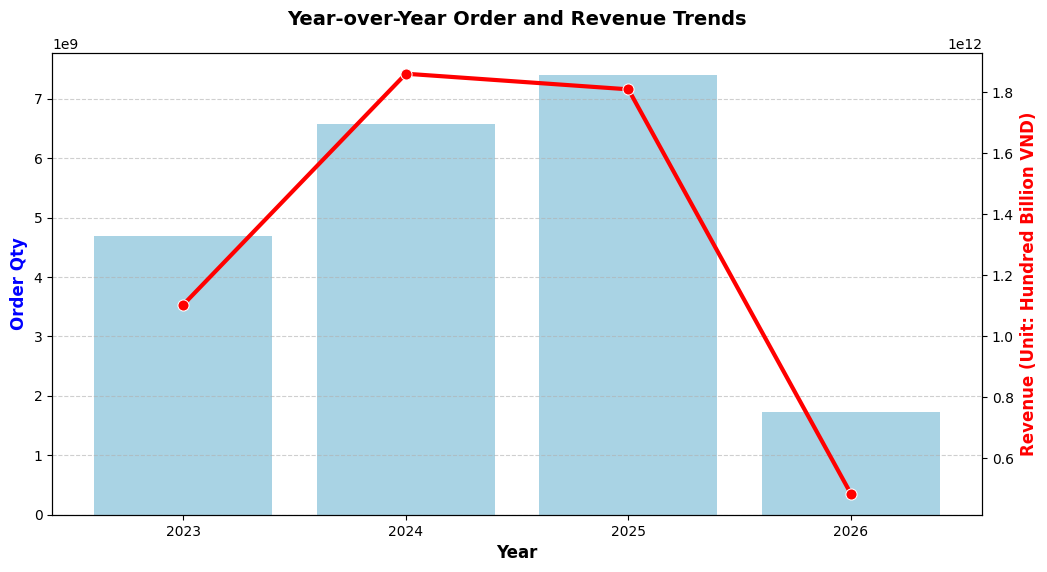

In [31]:
# 1. Create a figure and axis for the first plot (Order Qty)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Draw Bar Plot for Order Qty (left Y-axis)
sns.barplot(data=annual_sum_qty_revenue, x='so_year', y='Order Qty', color='skyblue', alpha=0.8, ax=ax1)
ax1.set_ylabel('Order Qty', color='blue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12,fontweight='bold')


# 3. Create the second axis (ax2) sharing the same X-axis as ax1
ax2 = ax1.twinx()

# 4. Draw Line Plot for Revenue (right Y-axis)
# Note: amount_so_eleven_millions is the scaled value for better visualization
sns.lineplot(data=annual_sum_qty_revenue, x=ax1.get_xticks(), y='amount_so',
             color='red', marker='o', markersize=8, linewidth=3, ax=ax2)
ax2.set_ylabel('Revenue (Unit: Hundred Billion VND)', color='red', fontsize=12, fontweight='bold')

# 5. Customize the plot for better aesthetics
plt.title('Year-over-Year Order and Revenue Trends', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

plt.show();

Comment: 
- From 2023 to 2025, orders grew steadily by 1.5x. Revenue saw a sharp spike between 2023 and 2024 (from ~1.1 to 1.8+ hundred billion VND), maintaining this high level into 2025. Thus, 2024-2025 stands out as the period of peak stability for both orders and revenue.

- Despite higher order volume in 2025, revenue dipped slightly from its 2024 peak. This indicates a lower average unit price or increased discounting and promotional expenses in 2025.

##### 2.2. Total Revenue of Category by Years

In [32]:
annual_sum_so = so_item_sale.groupby(by = ["Item Group", "so_year"])[["Order Qty", "amount_so"]].sum().reset_index()

item_group_so = [
                "Internal Finish Products",
                "External Finish Products", 
                "Services Processing Products",
                "OutSource Processing",
                "Screws"
                ]

annual_sum_so                           = annual_sum_so[annual_sum_so["Item Group"].isin(item_group_so)]
annual_sum_so["amount_so_ten_millions"] = (annual_sum_so["amount_so"]/ (10**7)).round()
annual_sum_so

,Item Group,so_year,Order Qty,amount_so,amount_so_ten_millions
4,Internal Finish Products,2023,1628295,4.015955e+10,4016.0
5,Internal Finish Products,2024,2421097,4.937799e+10,4938.0
6,Internal Finish Products,2025,1774465,1.854512e+10,1855.0
7,Internal Finish Products,2026,781407,2.351910e+10,2352.0
12,OutSource Processing,2023,31274198,7.072985e+10,7073.0
13,OutSource Processing,2024,86195073,3.866481e+11,38665.0
14,OutSource Processing,2025,78735245,6.208158e+11,62082.0
15,OutSource Processing,2026,30326114,1.621123e+11,16211.0
16,Screws,2023,4654719720,9.819811e+11,98198.0
17,Screws,2024,6486459716,1.407575e+12,140757.0


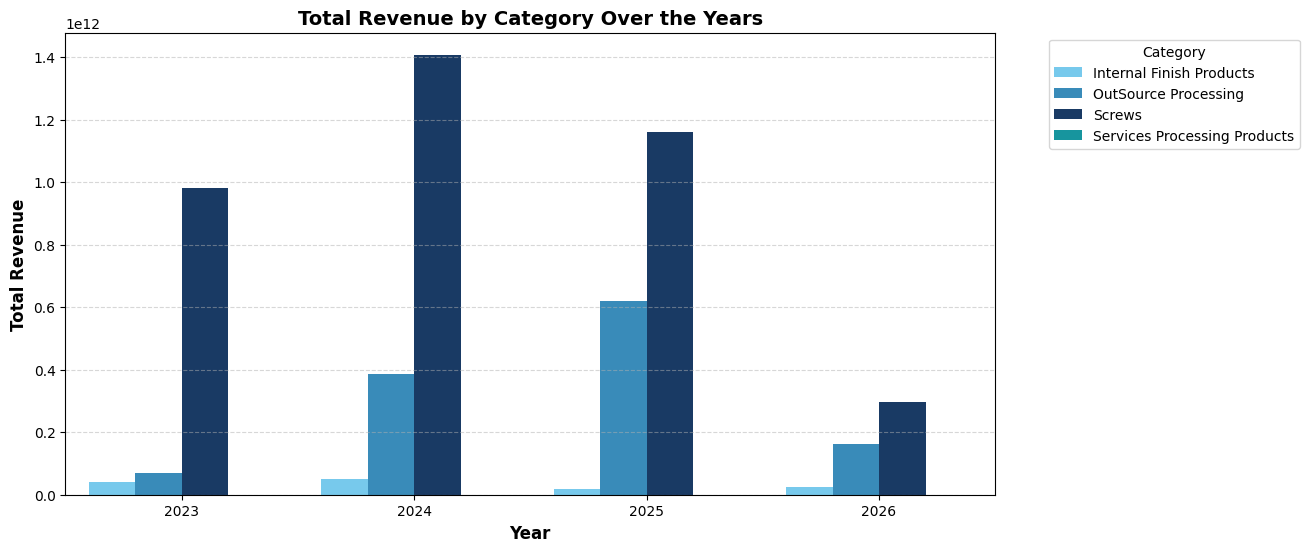

In [33]:
plt.figure(figsize=(12, 6))
color_year  = ["#64d1ff", "#2491ce", "#0d3870", "#00a9b5"]# Define a color map for the bars

ax_annual = sns.barplot(data=annual_sum_so, 
                        x='so_year', 
                        y='amount_so', 
                        hue='Item Group', 
                        palette=color_year)
plt.title('Total Revenue by Category Over the Years', fontsize = 14, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue', fontsize=12, fontweight='bold')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show();

Comment:
- Screws are the primary revenue driver, while Services Processing Product remains insignificant. 
- Fastener sales surged to a 1.4 trillion VND peak before retreating to 1.1 trillion VND. This performance directly accounts for the overall revenue dip in 2025 following the 2024 peak
- Notably, processed goods surged from 400 billion VND in 2023 to 600 billion VND in 2025. This growth cushioned the impact of falling fastener sales, stabilizing the overall revenue

==> Next step: Analyzing the decreasing reason of revenue and ordeer quantity of screw by quarters

In [34]:
so_item_sale.columns

Index(['Customer Code', 'Customer Name', 'SO No', 'Item Code', 'Order Date',
       'Order Qty', 'Delivery Qty', 'Delivery Date', 'Estimate Stock in Date',
       'Issue Date', 'Remain Quantity', 'SO Status', 'so_year', 'so_month',
       'so_quarter', 'Document No', 'Company Code', 'Currency', 'Unit',
       'Price Type', 'Quantity', 'Unit Price', 'Unit Price VND', 'Date',
       'Accounting Code', 'Supplier Item Code', 'Maker Item Code',
       'Item Name (VN)', 'Item Name (EN)', 'Item Name (JP)', 'Maker',
       'Manage Volume', 'Item Type', 'Item Group', 'Item Category', 'Jan Code',
       'SPQ', 'Sub Category', 'Primary Unit', 'HS Code', 'Origin Of Goods',
       'Weight (Gram)', 'Status', 'amount_so'],
      dtype='str')

##### 2.3. Analysis of quarterly screws

In [35]:
so_item_sale_screw           = so_item_sale[so_item_sale["Item Group"] == "Screws"]
so_item_sale_screw_quarterly = so_item_sale.groupby(by = ["so_year", "so_quarter"])[["Order Qty", "amount_so"]].sum().reset_index()
so_item_sale_screw_quarterly

,so_year,so_quarter,Order Qty,amount_so
0,2023,1,805090845,2.560104e+11
1,2023,2,920134103,2.934778e+11
2,2023,3,1331256427,2.672108e+11
3,2023,4,1633647238,2.875034e+11
4,2024,1,1249326040,4.036360e+11
5,2024,2,1925219236,4.260597e+11
6,2024,3,1547375188,4.044295e+11
7,2024,4,1856421205,6.266606e+11
8,2025,1,1408717604,5.053090e+11
9,2025,2,1940090262,3.897715e+11


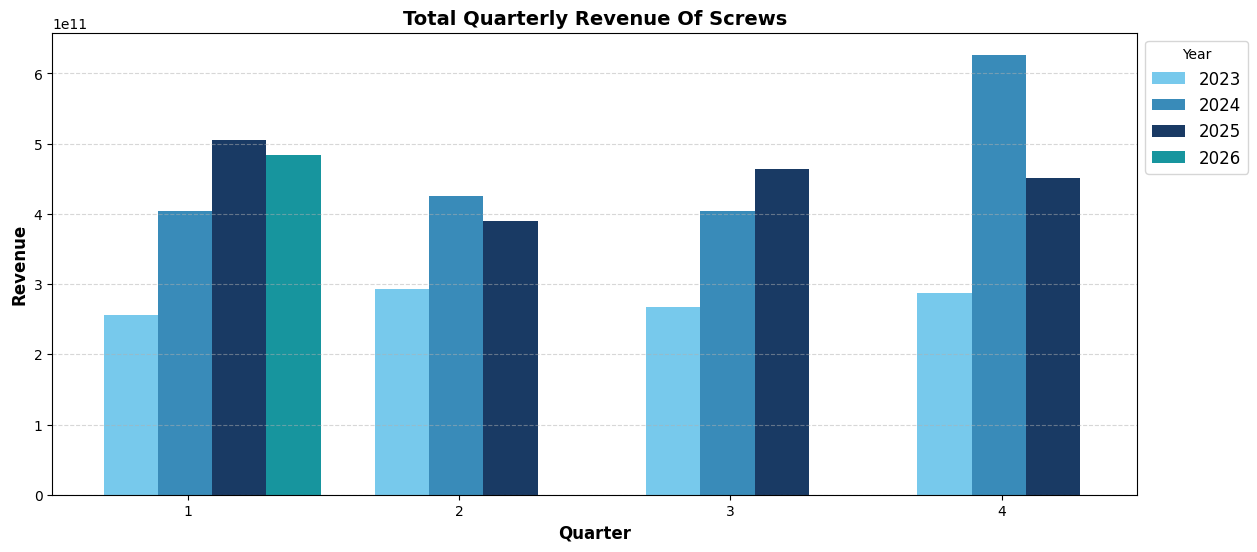

In [36]:
plt.figure(figsize=(14, 6))

ax_quarterly = sns.barplot(data= so_item_sale_screw_quarterly, x='so_quarter', y='amount_so', hue='so_year', palette=color_year)

for container in ax_quarterly.containers:    
    for bar in container:
        # Change the width of the bar
        # bar.get_width() returns the original width of the bar, you can adjust it as needed
        original_width = bar.get_width()
        new_width = original_width * 0.1 # adjust the width as needed
        bar.set_x(bar.get_x() + (original_width - new_width) / 2) # Align the bar to the center of the month position
        

plt.title('Total Quarterly Revenue Of Screws',fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=12, fontweight = 'bold')
plt.ylabel('Revenue', fontsize=12, fontweight = 'bold')
plt.legend(title='Year', fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show();

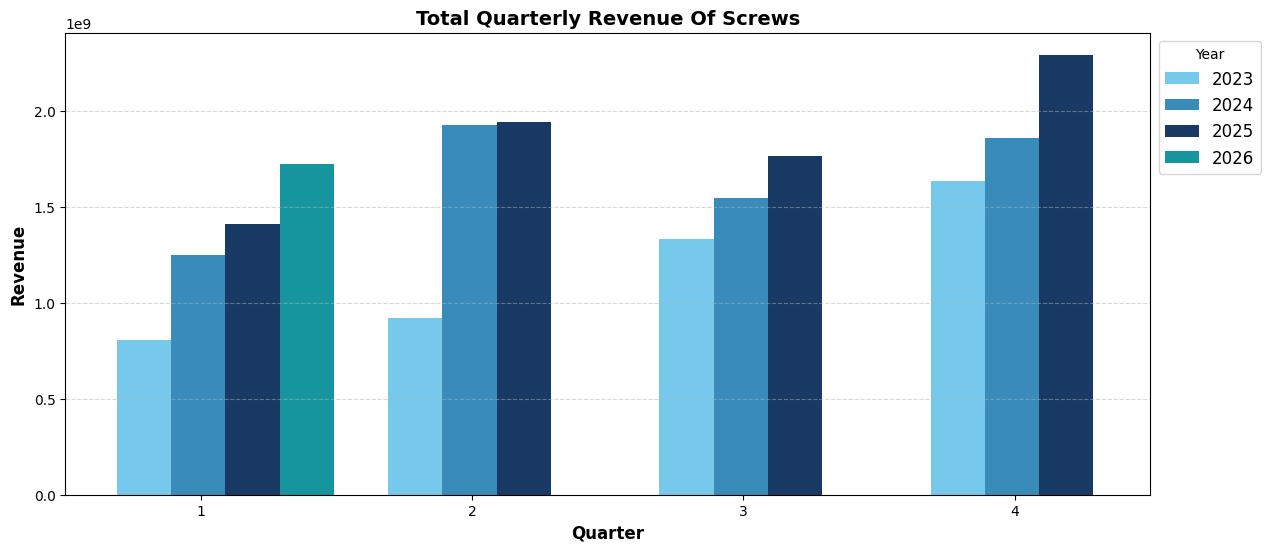

In [37]:
plt.figure(figsize=(14, 6))

ax_quarterly = sns.barplot(data= so_item_sale_screw_quarterly, x='so_quarter', y='Order Qty', hue='so_year', palette=color_year)

for container in ax_quarterly.containers:    
    for bar in container:
        # Change the width of the bar
        # bar.get_width() returns the original width of the bar, you can adjust it as needed
        original_width = bar.get_width()
        new_width = original_width * 0.1 # adjust the width as needed
        bar.set_x(bar.get_x() + (original_width - new_width) / 2) # Align the bar to the center of the month position
        

plt.title('Total Quarterly Revenue Of Screws',fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=12, fontweight = 'bold')
plt.ylabel('Revenue', fontsize=12, fontweight = 'bold')
plt.legend(title='Year', fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show();

Comment:
- Fasteners see a Q4 surge annually due to year-end production spikes and customer inventory buildup.

- 2025 revenue dipped slightly in Q1 but fell sharply behind 2024 levels in the following quarters.

- Recommendation: Due to the distinct revenue drop in Q4 2025, we must re-evaluate unit prices, discounts, and overhead costs/wastage for the final quarter.

#### Question 2: Minimize air freight orders to reduce corporate expenditures

In [38]:
# Compare the quarterly PO with Air and Vessel transport method
track_po.head(4)

,Supplier Code,Supplier Name,PO No,Shipping Method,PO Date,Item Code,PO Qty,Received Qty,Remain Qty,Receiving Plan Date,PO Status,Amount,Customer Code,month_po,year_po,quarter_po,month_rpd,year_rpd
0,S00825,"Nhat Dang Quang CO.,LTD.",C00895-EMP152-230103-01,Car,2023-01-03,CABLE-TIE-300+5,50.0,50.0,0.0,2023-01-06,Closed,1250000.0,C00895,1,2023,1,1,2023
1,S00825,"Nhat Dang Quang CO.,LTD.",C00895-EMP152-230103-01,Car,2023-01-03,CABLE-TIE-500+8,1.0,1.0,0.0,2023-01-06,Closed,59000.0,C00895,1,2023,1,1,2023
2,S00721,"Kim Thiet Manufacturing Co., Ltd",C00664-EMP063-230103-01,Car,2023-01-03,014-135-02-C-02,3059.0,3059.0,0.0,2023-01-09,Closed,11624200.0,C00664,1,2023,1,1,2023
3,S00721,"Kim Thiet Manufacturing Co., Ltd",C00664-EMP063-230103-01,Car,2023-01-03,014-135-02-C-GRAY-02,3.0,3.0,0.0,2023-01-06,Closed,11400.0,C00664,1,2023,1,1,2023


In [39]:
track_po_air_vessel                   = track_po[track_po["Shipping Method"].isin(["Air", "Vessel"])]
track_po_air_vessel_quarterly         = track_po_air_vessel.groupby(by = ["year_po", "quarter_po", "Shipping Method"])["Amount"].sum().reset_index()
track_po_air_vessel_quarterly["Time"] = track_po_air_vessel_quarterly['year_po'].astype(str) + '-Q' + track_po_air_vessel_quarterly['quarter_po'].astype(str)
track_po_air_vessel_quarterly.head()

,year_po,quarter_po,Shipping Method,Amount,Time
0,2023,1,Air,2.152273e+06,2023-Q1
1,2023,1,Vessel,1.801286e+07,2023-Q1
2,2023,2,Air,2.605519e+06,2023-Q2
3,2023,2,Vessel,1.237719e+07,2023-Q2
4,2023,3,Air,2.391272e+06,2023-Q3


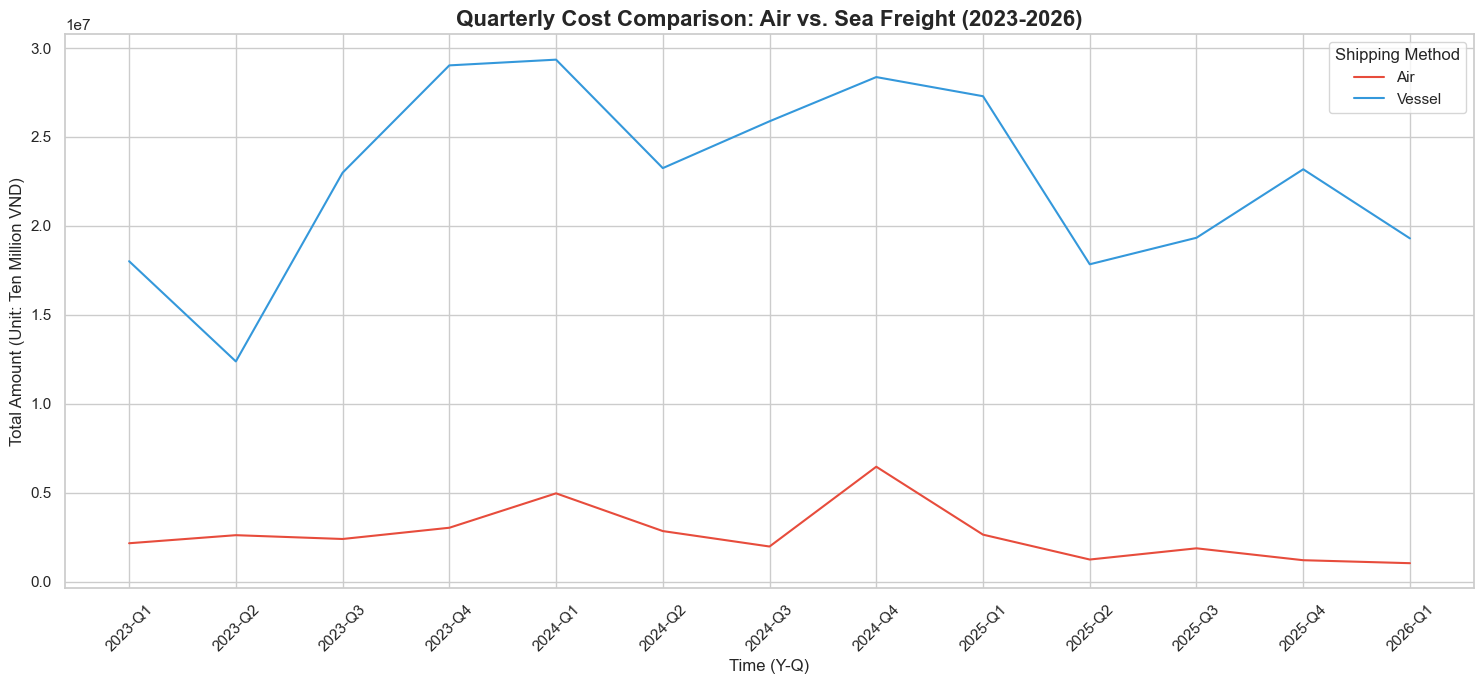

In [40]:
# Thiết lập kích thước biểu đồ
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

# Vẽ biểu đồ cột nhóm
ax = sns.lineplot(
    data    = track_po_air_vessel_quarterly, 
    x       = 'Time', 
    y       ='Amount', 
    hue     ='Shipping Method',
    palette = {'Air': '#e74c3c', 'Vessel': '#3498db'} # Đỏ cho Air, Xanh cho Vessel
)


plt.title('Quarterly Cost Comparison: Air vs. Sea Freight (2023-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Time (Y-Q)', fontsize=12)
plt.ylabel('Total Amount (Unit: Ten Million VND)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show();

Comment:
- Overall, Air costs remain at a very low level compared to sea freight, showing that the company is controlling the priority of vessel shipments well to save costs.
- Air costs tend to increase in Q4 annually, especially peaking at about 0.6 ten million VND in Q4/2024. The reason may be year-end delivery pressure or urgent orders forcing the purchasing department to use air freight to meet schedules.
- Notably, Air costs from Q2/2025 to Q1/2026 have been maintained at the lowest and most stable level in the entire period. This proves that your efforts to reduce the number of Air orders have brought real efficiency.

Proposal:
+ Need to place orders early to prepare for Q4 at the end of the year.
+ Continue maintaining the shift of items from Air to Vessel when production time allows to optimize profit margins.

#### Question 3: Check the items list with SO not completed and overstocked

In [44]:
# Show the SO with "In Process" status
so_in_process = so_item_sale[so_item_sale["SO Status"] == "In Process"]

# Item Code with "In Process" status
so_in_process = so_in_process.groupby(by = "Item Code")["Order Qty"].sum().reset_index()
so_in_process.head()

,Item Code,Order Qty
0,1A0CY6B0,1200
1,2130301-3+08-002,30000
2,2140301-2+05-002,7132860
3,47GS00490,53450
4,5100200-8+12-060,2800


In [68]:
# The items with in these warehouses ("Screws", "Products", "Outsource") are ready to deliver to customers. 
# We need to check the quantity of these items in the warehouses to ensure that we can meet the demand of customers.

warehouse_ready         = ["Screws", "Products", "Outsource"]

warehouse_pending       = ["Assembly", "Check Before Deliverring To Supplier", "Check Finish Products",
                           "Cut", "Electric Shoot", 
                           "Lathe CNC", "Lathe CNC 1", "Lathe CNC 2", "Lathe CNC 3", "Lathe CNC 4",
                           "Mill CNC", "Mill CNC 1", "Mill CNC 2", "Mill CNC 3", "Mill CNC 4",
                           "Make Bari", "Plating", "Painting", "Pack Finish Products", "Wash", "Thermal Refining", "Thermal Treatment"
                           ]

inventory_ready         = inventory[inventory["Warehouse"].isin(warehouse_ready)]

# Merge the so_in_process with the inventory_ready to check if any item codes of SO with "In Process" status have enough quantity in the warehouses to meet the demand of customers.
so_in_process_inventory = so_in_process.merge(inventory_ready, on = "Item Code", how = "left")

so_in_process_inventory = so_in_process_inventory.rename(columns={'OK': 'Ready Qty'})
so_in_process_inventory.head()


,Item Code,Order Qty,STT,Item Group,Item Category,Sub Category,Unit,Warehouse,Minimum Stock,Reservation,Avaliable,Ready Qty,QA Waiting,Remade,NG,Total
0,1A0CY6B0,1200,897.0,Internal Finish Products,Internal Finish Products,Internal Finish Products,Pcs,Products,100.0,0.0,2.0,2.0,0.0,0.0,0.0,2.0
1,2130301-3+08-002,30000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2140301-2+05-002,7132860,1422.0,Screws,Sems Screw,(+) Pan P=4,Pcs,Screws,20224.0,1960.0,7881.0,9841.0,0.0,0.0,0.0,9841.0
3,47GS00490,53450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5100200-8+12-060,2800,3472.0,Screws,Cap Screw,Cap Screw,Pcs,Screws,600.0,73.0,127.0,200.0,0.0,0.0,0.0,200.0


In [69]:
# List of item codes with Pending status in the warehouses
item_pending = inventory[inventory["Warehouse"].isin(warehouse_pending)]
item_pending = item_pending.groupby(by = "Item Code")["OK"].sum().reset_index()

item_pending = item_pending.rename(columns={'OK': 'Pending Qty'})
item_pending.head()

,Item Code,Pending Qty
0,002-C49-104-2-02,32.0
1,010-159-00-1-02,0.0
2,014-135-02-C-02,0.0
3,014-135-02-C-GRAY-02,23.0
4,014-137-01-C-02,0.0


In [64]:
# List of item codes with Pending PO status
track_po_pending  = track_po[track_po["PO Status"].isin(["In Process", "New"])]
track_po_pending  = track_po_pending.groupby(by = "Item Code")["PO Qty"].sum().reset_index()
track_po_pending

,Item Code,PO Qty
0,010-158-00-1-02,1000.0
1,014-135-02-C-02,3000.0
2,014-135-02-C-GRAY-02,9000.0
3,014-136-01-C-02,3000.0
4,014-137-01-C-02,1000.0
...,...,...
769,Y20199101318,22.0
770,Y20199540380,5.0
771,YDBSO-69570-ZI,15000.0
772,ZL-60D,1.0


In [91]:
# Filtering the lacking quantity of SO
filter_lack = pd.merge(so_in_process_inventory, item_pending, on = "Item Code", how = "left")
filter_lack = pd.merge(filter_lack, track_po_pending,      on = "Item Code", how = "left")

necessary_columns = ["Order Qty","Minimum Stock", "Ready Qty", "Pending Qty", "PO Qty"]

for column in necessary_columns:
    filter_lack[column] = filter_lack[column].fillna(0)

filter_lack["Lacking Qty"] = (filter_lack["Ready Qty"] + filter_lack["Pending Qty"]) - (filter_lack["PO Qty"] + filter_lack["Order Qty"] + filter_lack["Minimum Stock"])

filter_lack = filter_lack[["Item Code"] + necessary_columns + ["Lacking Qty"]]
filter_lack.head()

,Item Code,Order Qty,Minimum Stock,Ready Qty,Pending Qty,PO Qty,Lacking Qty
0,1A0CY6B0,1200,100.0,2.0,0.0,0.0,-1298.0
1,2130301-3+08-002,30000,0.0,0.0,0.0,2000.0,-32000.0
2,2140301-2+05-002,7132860,20224.0,9841.0,0.0,156000.0,-7299243.0
3,47GS00490,53450,0.0,0.0,1545.0,0.0,-51905.0
4,5100200-8+12-060,2800,600.0,200.0,0.0,0.0,-3200.0


In [92]:
# Filter the items with lacking quantity > 0
df_filter_lack = filter_lack[filter_lack["Lacking Qty"] <= 0]
df_filter_lack.head()

,Item Code,Order Qty,Minimum Stock,Ready Qty,Pending Qty,PO Qty,Lacking Qty
0,1A0CY6B0,1200,100.0,2.0,0.0,0.0,-1298.0
1,2130301-3+08-002,30000,0.0,0.0,0.0,2000.0,-32000.0
2,2140301-2+05-002,7132860,20224.0,9841.0,0.0,156000.0,-7299243.0
3,47GS00490,53450,0.0,0.0,1545.0,0.0,-51905.0
4,5100200-8+12-060,2800,600.0,200.0,0.0,0.0,-3200.0


In [ ]:
# Filter the items with lacking quantity > 0 and the portion is over 4 times compared to minimum stock
df_filter_overstock = filter_lack[(filter_lack["Lacking Qty"] > 0) & (filter_lack["Lacking Qty"] > 4 * filter_lack["Minimum Stock"])]
df_filter_overstock.head()


,Item Code,Order Qty,Minimum Stock,Ready Qty,Pending Qty,PO Qty,Lacking Qty


Comment:
- The lacking items must be urgently replenished to the warehouse.
- The overstocked items should be released early and implemented an order restriction to optimize cash flows